In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [23]:
# 1. УДАЛЕНИЕ ТОЛЬКО КОЛОНОК С УТЕЧКОЙ ДАННЫХ (в начале обработки данных)
data = pd.read_csv('D:/my_ML/SpbStu/diploma_polytech/data/raw/vehicle_ins_data_1.csv', sep = ";",index_col= False)
data['claim_prob'] = (data['N_claims_year'] == 1).astype(int)
leak_columns = ['ID', 'N_claims_year', 'Cost_claims_year', 'N_claims_history', 'R_Claims_history']

print("Исходные колонки:", data.columns.tolist())
print(f"\nУдаляем колонки с утечкой данных: {leak_columns}")
data = data.drop(columns=[col for col in leak_columns if col in data.columns], errors='ignore')
print("Колонки после удаления утечек:", data.columns.tolist())

# 2. Создание target (оставляем как есть)



Исходные колонки: ['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal', 'Date_birth', 'Date_driving_licence', 'Distribution_channel', 'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'Lapse', 'Date_lapse', 'Payment', 'Premium', 'Cost_claims_year', 'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk', 'Area', 'Second_driver', 'Year_matriculation', 'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Type_fuel', 'Length', 'Weight', 'claim_prob']

Удаляем колонки с утечкой данных: ['ID', 'N_claims_year', 'Cost_claims_year', 'N_claims_history', 'R_Claims_history']
Колонки после удаления утечек: ['Date_start_contract', 'Date_last_renewal', 'Date_next_renewal', 'Date_birth', 'Date_driving_licence', 'Distribution_channel', 'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'Lapse', 'Date_lapse', 'Payment', 'Premium', 'Type_risk', 'Area', 'Second_driver', 'Year_matriculation', 'Power', 'Cylinder_capacity', 'Value_vehicle',

C:\Users\andre\AppData\Local\Temp\ipykernel_30216\2075709981.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('D:/my_ML/SpbStu/diploma_polytech/data/raw/vehicle_ins_data_1.csv', sep = ";",index_col= False)


In [24]:
# 3. ПРОДОЛЖАЕМ ОБРАБОТКУ ДАННЫХ (остальной код без изменений)
# 1. Сначала обработать ВСЕ датовые колонки, если они существуют
date_columns = ['Date_birth', 'Date_driving_licence']

# Создаем список существующих датовых колонок
existing_date_columns = [col for col in date_columns if col in data.columns]

# Проверим, какие датовые колонки нашлись
print("Существующие датовые колонки для обработки:", existing_date_columns)

if not existing_date_columns:
    print("Предупреждение: Датовые колонки не найдены в DataFrame.")
else:
    for col in existing_date_columns:
        data[col] = pd.to_datetime(data[col], format='%d/%m/%Y', errors='coerce')

    # 2. Извлечь числовые признаки из существующих дат
    reference_date = pd.to_datetime('2019-12-31')
    
    if 'Date_birth' in data.columns:
        data['Age'] = (reference_date - data['Date_birth']).dt.days // 365
    
    if 'Date_driving_licence' in data.columns:
        data['Driving_experience'] = (reference_date - data['Date_driving_licence']).dt.days // 365

    

# 2. Извлечь числовые признаки из дат
reference_date = pd.to_datetime('2019-12-31')
data['Age'] = (reference_date - data['Date_birth']).dt.days // 365
data['Driving_experience'] = (reference_date - data['Date_driving_licence']).dt.days // 365

# 3. Удалить исходные датовые колонки
data = data.drop(columns=date_columns)
data = data.drop(columns=existing_date_columns, errors='ignore')
# 4. Обработать категориальные переменные
categorical_cols = ['Type_fuel']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# 5. Убедиться, что все данные числовые
data = data.apply(pd.to_numeric, errors='coerce')
X = data.drop(columns=['claim_prob'])
y = data['claim_prob']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 6. Обработка пропущенных значений
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test) # Только transform!

X_train = pd.DataFrame(X_train_imputed, columns=imputer.get_feature_names_out())
X_test = pd.DataFrame(X_test_imputed, columns=imputer.get_feature_names_out())



# Разделение на обучающую и тестовую выборки

# После получения X_train, X_test (но ДО обучения модели)
# print("\n=== АНАЛИЗ FEATURE IMPORTANCE ПО IV ===")

# def calculate_iv(feature, target):
#     """Вычисляет Information Value (IV) для признака"""
#     if feature.dtype in ['int64', 'float64']:
#         # Дискретизация на 10 бинов
#         bins = pd.qcut(feature, q=10, duplicates='drop', labels=False)
#     else:
#         bins = feature
    
#     df = pd.DataFrame({'bin': bins.astype(str), 'target': target})
#     grouped = df.groupby('bin')['target'].agg(['count', 'sum'])
#     grouped['non_events'] = grouped['count'] - grouped['sum']
    
#     total_events = grouped['sum'].sum()
#     total_non_events = grouped['non_events'].sum()
    
#     if total_events == 0 or total_non_events == 0:
#         return 0.0
        
#     # Считаем ДОЛИ (пропорции) от общего числа в каждом бине
#     grouped['pct_events'] = grouped['sum'] / total_events
#     grouped['pct_non_events'] = grouped['non_events'] / total_non_events
    
#     # WOE = ln(%_non_events / %_events)
#     # Добавляем 1e-10 для защиты от деления на ноль и log(0)
#     grouped['woe'] = np.log((grouped['pct_non_events'] + 1e-10) / (grouped['pct_events'] + 1e-10))
    
#     # IV = (%_non_events - %_events) * WOE
#     grouped['iv_contrib'] = (grouped['pct_non_events'] - grouped['pct_events']) * grouped['woe']
    
#     return grouped['iv_contrib'].sum()


# # Вычисляем IV для всех признаков
# feature_names = X_train.columns.tolist()
# iv_scores = {}
# for name in feature_names:
#     iv = calculate_iv(X_train[name], y_train)
#     iv_scores[name] = iv

# iv_df = pd.DataFrame(list(iv_scores.items()), columns=['Feature', 'IV']).sort_values('IV', ascending=False)
# print(iv_df)

Существующие датовые колонки для обработки: ['Date_birth', 'Date_driving_licence']


d:\My_ML\.venv\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['Date_start_contract' 'Date_last_renewal' 'Date_next_renewal'
 'Date_lapse']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
d:\My_ML\.venv\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['Date_start_contract' 'Date_last_renewal' 'Date_next_renewal'
 'Date_lapse']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



=== АНАЛИЗ FEATURE IMPORTANCE ПО IV (optbinning) ===
                    name        iv
0                  Lapse  0.098544
1                Premium   0.05843
2                 Weight  0.057588
3                N_doors  0.057281
4          Value_vehicle  0.055342
5                 Length    0.0542
6      Cylinder_capacity  0.051004
7                  Power  0.050575
8              Seniority  0.044038
9              Type_risk  0.043246
10               Payment  0.039426
11    Driving_experience  0.023057
12                   Age  0.018032
13    Year_matriculation  0.016558
14             Type_fuel  0.016004
15         Second_driver  0.006613
16  Distribution_channel  0.006483
17          Max_products  0.002542
18     Policies_in_force  0.002502
19          Max_policies  0.002453
20                  Area  0.001084


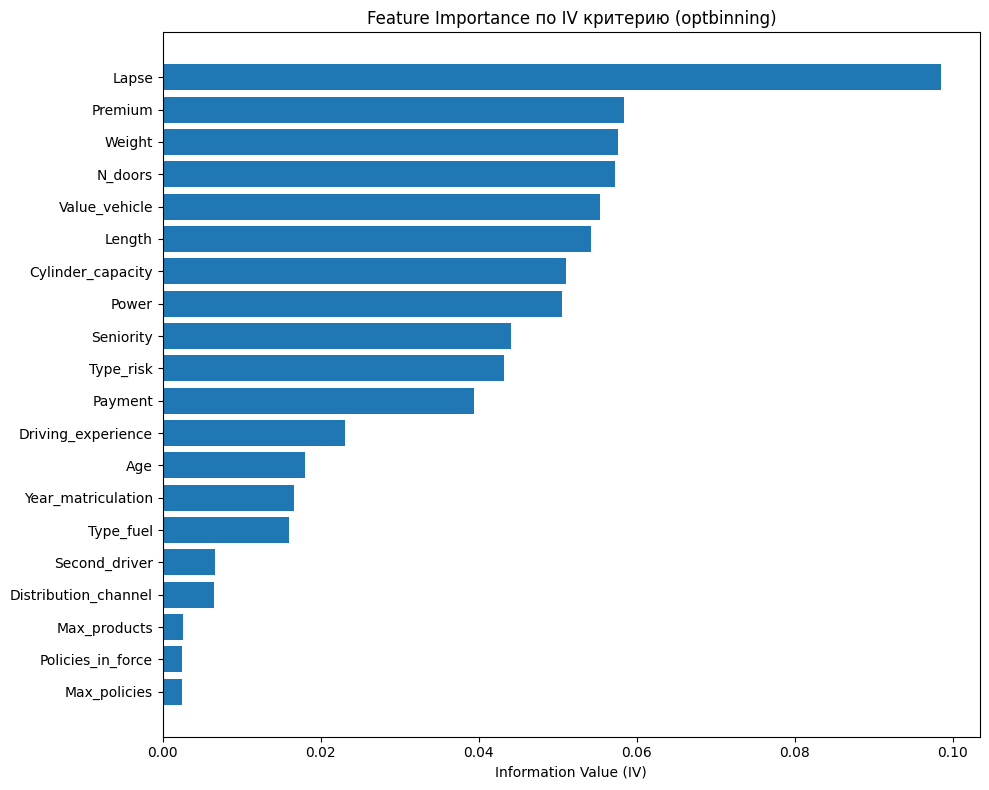

In [25]:
from optbinning import BinningProcess
import matplotlib.pyplot as plt

print("\n=== АНАЛИЗ FEATURE IMPORTANCE ПО IV (optbinning) ===")

# Получаем список всех признаков
feature_names = X_train.columns.tolist()

# Инициализируем процесс биннинга для всех признаков
# Так как вы ранее уже закодировали категориальные признаки (LabelEncoder), 
# optbinning отлично справится с ними как с числовыми/порядковыми.
binning_process = BinningProcess(variable_names=feature_names)

# Обучаем процесс на тренировочной выборке
# ytrain передаем в виде одномерного массива (numpy array)
binning_process.fit(X_train, y_train.values.ravel())

# Получаем сводную таблицу с результатами
summary_df = binning_process.summary()

# Оставляем только имя признака и его IV, сортируем по убыванию
iv_df = summary_df[['name', 'iv']].sort_values(by='iv', ascending=False).reset_index(drop=True)
print(iv_df)

# Визуализация топ-20 признаков
plt.figure(figsize=(10, 8))
# Если признаков меньше 20, берем сколько есть
top_n = min(20, len(iv_df))
plt.barh(iv_df['name'][:top_n], iv_df['iv'][:top_n])
plt.xlabel('Information Value (IV)')
plt.title('Feature Importance по IV критерию (optbinning)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
# 4. УДАЛЕНИЕ НЕЗНАЧИМЫХ ПРИЗНАКОВ (IV < 0.02)
iv_threshold = 0.02

# Отбираем значимые и незначимые
significant_features = iv_df[iv_df['iv'] >= iv_threshold]['name'].tolist()
insignificant_features = iv_df[iv_df['iv'] < iv_threshold]['name'].tolist()

print(f"\nЗначимые признаки (IV >= {iv_threshold}): {len(significant_features)}")
print(f"Оставляем: {significant_features}")
print(f"\nУдаляем незначимые признаки (IV < {iv_threshold}): {len(insignificant_features)}")
print(f"Удаляем: {insignificant_features}")

# Обновляем датасеты только значимыми признаками
X_train_sig = X_train[significant_features]
X_test_sig = X_test[significant_features]

print(f"\nРазмер X_train ДО фильтрации: {X_train.shape}")
print(f"Размер X_train ПОСЛЕ фильтрации: {X_train_sig.shape}")

# Пересоздаем тензоры PyTorch с отфильтрованными данными
scaler_sig = StandardScaler()
X_train_scaled_sig = scaler_sig.fit_transform(X_train_sig)
X_test_scaled_sig = scaler_sig.transform(X_test_sig)

X_traintensor_sig = torch.tensor(X_train_scaled_sig, dtype=torch.float32)
y_traintensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_testtensor_sig = torch.tensor(X_test_scaled_sig, dtype=torch.float32)
y_testtensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Сохраняем результаты анализа
iv_df.to_csv('feature_importance_iv_analysis.csv', index=False)
print("\nРезультаты сохранены в 'feature_importance_iv_analysis.csv'")


Значимые признаки (IV >= 0.02): 12
Оставляем: ['Lapse', 'Premium', 'Weight', 'N_doors', 'Value_vehicle', 'Length', 'Cylinder_capacity', 'Power', 'Seniority', 'Type_risk', 'Payment', 'Driving_experience']

Удаляем незначимые признаки (IV < 0.02): 9
Удаляем: ['Age', 'Year_matriculation', 'Type_fuel', 'Second_driver', 'Distribution_channel', 'Max_products', 'Policies_in_force', 'Max_policies', 'Area']

Размер X_train ДО фильтрации: (84444, 21)
Размер X_train ПОСЛЕ фильтрации: (84444, 12)

Результаты сохранены в 'feature_importance_iv_analysis.csv'


In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Создание нейронной сети
class InsuranceNet(nn.Module):
    def __init__(self, input_size):
        super(InsuranceNet, self).__init__()
        
        # --- Слои ---
        self.layer1 = nn.Linear(input_size, 72)
        self.bn1 = nn.BatchNorm1d(72)
        self.dropout1 = nn.Dropout(0.2)
        
        self.layer2 = nn.Linear(72, 36)
        self.bn2 = nn.BatchNorm1d(36)
        self.dropout2 = nn.Dropout(0.1)

        self.layer3 = nn.Linear(36, 18)
        #self.bn3 = nn.BatchNorm1d(16)
        
        self.output = nn.Linear(18, 1)
        
        # --- Активации ---
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # 1-й слой
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        # 2-й слой
        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        #x = self.dropout2(x)
        # 3-й слой
        x = self.layer3(x)
        #x = self.bn3(x)
        x = self.relu(x)

        # Выход (вероятность от 0 до 1)
        #x = self.sigmoid(self.output(x))
        x = self.output(x)
        return x

# --- Инициализация модели ---
input_size = X_traintensor_sig.shape[1]
model = InsuranceNet(input_size)

# --- Функция потерь и оптимизатор ---
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()

# Переводим в тензор. Важно: размерность должна совпадать с выходом модели
pos_weight_val = torch.tensor([num_negatives / num_positives], dtype=torch.float32)

print(f"Рассчитанный вес положительного класса: {pos_weight_val.item():.2f}")

# 2. Инициализация функции потерь (замените ваш старый nn.BCELoss на это)
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
# criterion = nn.BCELoss()  # можно заменить на FocalLoss при сильном дисбалансе
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        """
        alpha: Вес для редкого класса. Обычно равен доле редкого класса или 0.25.
        gamma: Фокусирующий параметр (обычно от 1 до 5). Чем выше, тем больше фокус на сложных примерах.
        """
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs - сырые логиты (выход линейного слоя без сигмоиды)
        
        # Сначала вычисляем стандартную кросс-энтропию (без усреднения)
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        
        # Вычисляем pt (вероятность правильного предсказания)
        # Математически: pt = exp(-BCE)
        pt = torch.exp(-bce_loss)
        
        # Основная формула Focal Loss
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# 2. Инициализация функции потерь
# alpha можно задать статично (например, 0.25) или рассчитать как num_pos / (num_pos + num_neg)
criterion = BinaryFocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)


Рассчитанный вес положительного класса: 9.98


In [40]:
# 5. ОБУЧЕНИЕ МОДЕЛИ НА ОТФИЛЬТРОВАННЫХ ПРИЗНАКАХ
input_size_sig = X_traintensor_sig.shape[1]
print(f"\nНовый input_size для модели: {input_size_sig}")

# Обновляем модель с новым input_size
model = InsuranceNet(input_size_sig)  # Ваша существующая архитектура

# Дальше идет обучение как раньше, но используем X_traintensor_sig и X_testtensor_sig
# Заменяем все X_traintensor -> X_traintensor_sig, X_testtensor -> X_testtensor_sig

print("\n=== МОДЕЛЬ ОБУЧАЕТСЯ НА ОТФИЛЬТРОВАННЫХ ЗНАЧИМЫХ ПРИЗНАКАХ ===")


Новый input_size для модели: 12

=== МОДЕЛЬ ОБУЧАЕТСЯ НА ОТФИЛЬТРОВАННЫХ ЗНАЧИМЫХ ПРИЗНАКАХ ===


In [41]:
# Обучение модели
epochs = 500
losses =[]
epochs_plt =[]
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_traintensor_sig)
    loss = criterion(outputs, y_traintensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        losses.append(loss.item())
        epochs_plt.append(epoch+1)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [10/500], Loss: 0.0649
Epoch [20/500], Loss: 0.0649
Epoch [30/500], Loss: 0.0649
Epoch [40/500], Loss: 0.0649
Epoch [50/500], Loss: 0.0649
Epoch [60/500], Loss: 0.0649
Epoch [70/500], Loss: 0.0648
Epoch [80/500], Loss: 0.0649
Epoch [90/500], Loss: 0.0649
Epoch [100/500], Loss: 0.0648
Epoch [110/500], Loss: 0.0649
Epoch [120/500], Loss: 0.0649
Epoch [130/500], Loss: 0.0649
Epoch [140/500], Loss: 0.0649
Epoch [150/500], Loss: 0.0648
Epoch [160/500], Loss: 0.0648
Epoch [170/500], Loss: 0.0648
Epoch [180/500], Loss: 0.0649
Epoch [190/500], Loss: 0.0649
Epoch [200/500], Loss: 0.0649
Epoch [210/500], Loss: 0.0649
Epoch [220/500], Loss: 0.0648
Epoch [230/500], Loss: 0.0648
Epoch [240/500], Loss: 0.0648
Epoch [250/500], Loss: 0.0649
Epoch [260/500], Loss: 0.0649
Epoch [270/500], Loss: 0.0649
Epoch [280/500], Loss: 0.0649
Epoch [290/500], Loss: 0.0649
Epoch [300/500], Loss: 0.0648
Epoch [310/500], Loss: 0.0649
Epoch [320/500], Loss: 0.0648
Epoch [330/500], Loss: 0.0648
Epoch [340/500], Lo

Text(0, 0.5, 'Loss function')

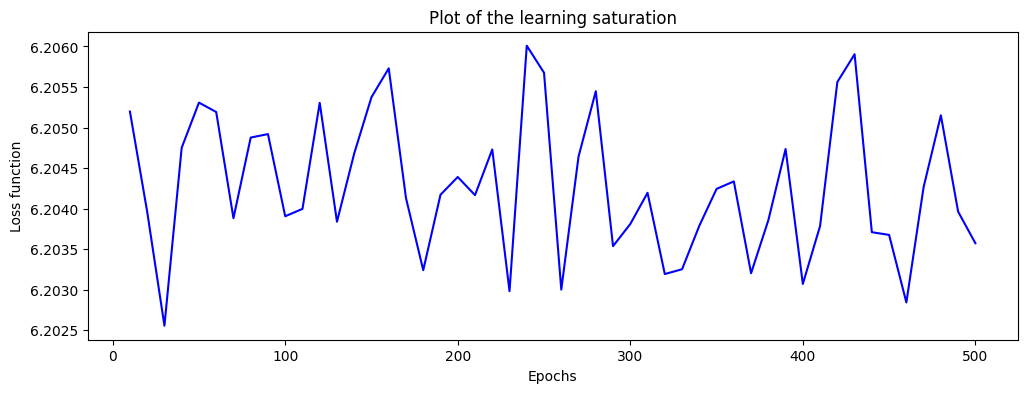

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(epochs_plt, losses, label='Plot of the learning saturation', color='blue')
plt.title('Plot of the learning saturation')
plt.xlabel('Epochs')
plt.ylabel('Loss function')

In [42]:
# Оценка модели
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_testtensor_sig).numpy()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)

# Метрики
roc_auc = roc_auc_score(y_test, y_pred_proba)
mae = mean_absolute_error(y_test, y_pred_proba)

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'MAE: {mae:.4f}')

with torch.no_grad():
    # train_proba = torch.sigmoid(model(X_traintensor_sig)).numpy().flatten()
    train_proba = model(X_traintensor_sig).numpy().flatten()
train_auc = roc_auc_score(y_train, train_proba)
print(f"\nROC-AUC на тренировочных данных: {train_auc:.4f}")
diff = train_auc-roc_auc
print(f"\nDifference:  {diff:.4f}")

ROC-AUC: 0.4662
MAE: 0.2965

ROC-AUC на тренировочных данных: 0.4684

Difference:  0.0021
